Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import torchvision.transforms as transforms
from PIL import Image
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score
from torch.utils.data import Dataset

# Outils de clustering et réduction de dimension
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split



Chargement du fichier généré au Notebook 2

In [2]:
df_features = pd.read_pickle("../features/features_mri_baseline.pkl")

print(f"Inventaire chargé : {len(df_features)} images.")
print(f"Colonnes disponibles : {df_features.columns.tolist()}")

Inventaire chargé : 1506 images.
Colonnes disponibles : ['path', 'label', 'resnet_final', 'resnet_inter', 'vgg_final', 'vgg_inter']


In [3]:

df_features = pd.read_pickle("../features/features_mri_baseline.pkl")

# Séparer les données avec et sans labels
df_labeled = df_features[df_features['label'] != 'Unknown'].copy()
df_unlabeled = df_features[df_features['label'] == 'Unknown'].copy()

# Split 60/10/30 UNIQUEMENT sur les données étiquetées (le jeu expert)
train_val_labeled, test_df = train_test_split(
    df_labeled, test_size=0.30, stratify=df_labeled['label'], random_state=42
)

train_labeled, val_df = train_test_split(
    train_val_labeled, test_size=(0.10/0.70), stratify=train_val_labeled['label'], random_state=42
)

# Le jeu de données pour entraîner le clustering : non-étiqueté + train étiqueté
df_train_clustering = pd.concat([df_unlabeled, train_labeled])

Définition des utilitaires de transformation et de gestion des données

In [4]:
class ApplyCLAHE(object):
    def __init__(self, clip_limit=3.0, tile_grid_size=(8, 8)):
        self.clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)

    def __call__(self, img):
        img_np = np.array(img)
        img_gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
        img_clahe = self.clahe.apply(img_gray)
        img_final = cv2.cvtColor(img_clahe, cv2.COLOR_GRAY2RGB)
        return Image.fromarray(img_final)

class MRIDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform
    def __len__(self):
        return len(self.dataframe)
    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image = Image.open(row['path']).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, row['label'], row['path']

## Baseline

Protocole de clustering et évaluation par l'indice de Rand ajusté (ARI)

In [5]:
# 1. On prépare les labels réels (uniquement pour la partie connue du jeu d'entraînement)
mask_labeled_train = df_train_clustering['label'] != 'Unknown'
true_labels_train = df_train_clustering[mask_labeled_train]['label'].map({'cancer': 1, 'normal': 0})

def run_clustering_protocol(layer_column):
    # A. Extraction
    X_train = np.stack(df_train_clustering[layer_column].values)
    X_val = np.stack(val_df[layer_column].values)
    X_test = np.stack(test_df[layer_column].values)
    
    # B. Standardisation (Fit sur le train uniquement)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)
    
    # C. PCA pour la visualisation
    pca = PCA(n_components=2)
    X_train_pca = pca.fit_transform(X_train_scaled)
    
    # D. Clustering K-Means k=2 (Fit sur le train uniquement)
    km = KMeans(n_clusters=2, n_init=10, random_state=42)
    train_clusters = km.fit_predict(X_train_scaled)
    
    # Application du modèle sur Validation et Test
    val_clusters = km.predict(X_val_scaled)
    test_clusters = km.predict(X_test_scaled)
    
    # Intégration des weak_labels aux dataframes
    df_train_clustering['weak_label'] = train_clusters
    val_df['weak_label'] = val_clusters
    test_df['weak_label'] = test_clusters
    
    # E. Calcul ARI (uniquement sur le train pour vérifier la pertinence)
    score_ari = adjusted_rand_score(true_labels_train, train_clusters[mask_labeled_train])
    
    return X_train_pca, train_clusters, score_ari

# Lancement du processus
X_pca_final, clus_final, ari_final = run_clustering_protocol('resnet_final')
X_pca_inter, clus_inter, ari_inter = run_clustering_protocol('resnet_inter')

print(f"Score ARI Couche Finale (Train) : {ari_final:.4f}")
print(f"Score ARI Couche Intermédiaire (Train) : {ari_inter:.4f}")

Score ARI Couche Finale (Train) : 0.3837
Score ARI Couche Intermédiaire (Train) : 0.5233


Sélection de la représentation optimale et génération des étiquettes faibles (Weak Labels)

In [6]:
# Choix automatique du meilleur modèle
if ari_inter > ari_final:
    winner_name = "Intermédiaire"
    X_pca_winner = X_pca_inter
    ari_winner = ari_inter
else:
    winner_name = "Finale"
    X_pca_winner = X_pca_final
    ari_winner = ari_final

print(f"Gagnant : {winner_name} avec un ARI de {ari_winner:.4f}")
print("Labellisation faible terminée. Les images d'entraînement ont maintenant un label IA dans 'weak_label'.")

Gagnant : Intermédiaire avec un ARI de 0.5233
Labellisation faible terminée. Les images d'entraînement ont maintenant un label IA dans 'weak_label'.


Analyse comparative des projections PCA et validation visuelle des clusters

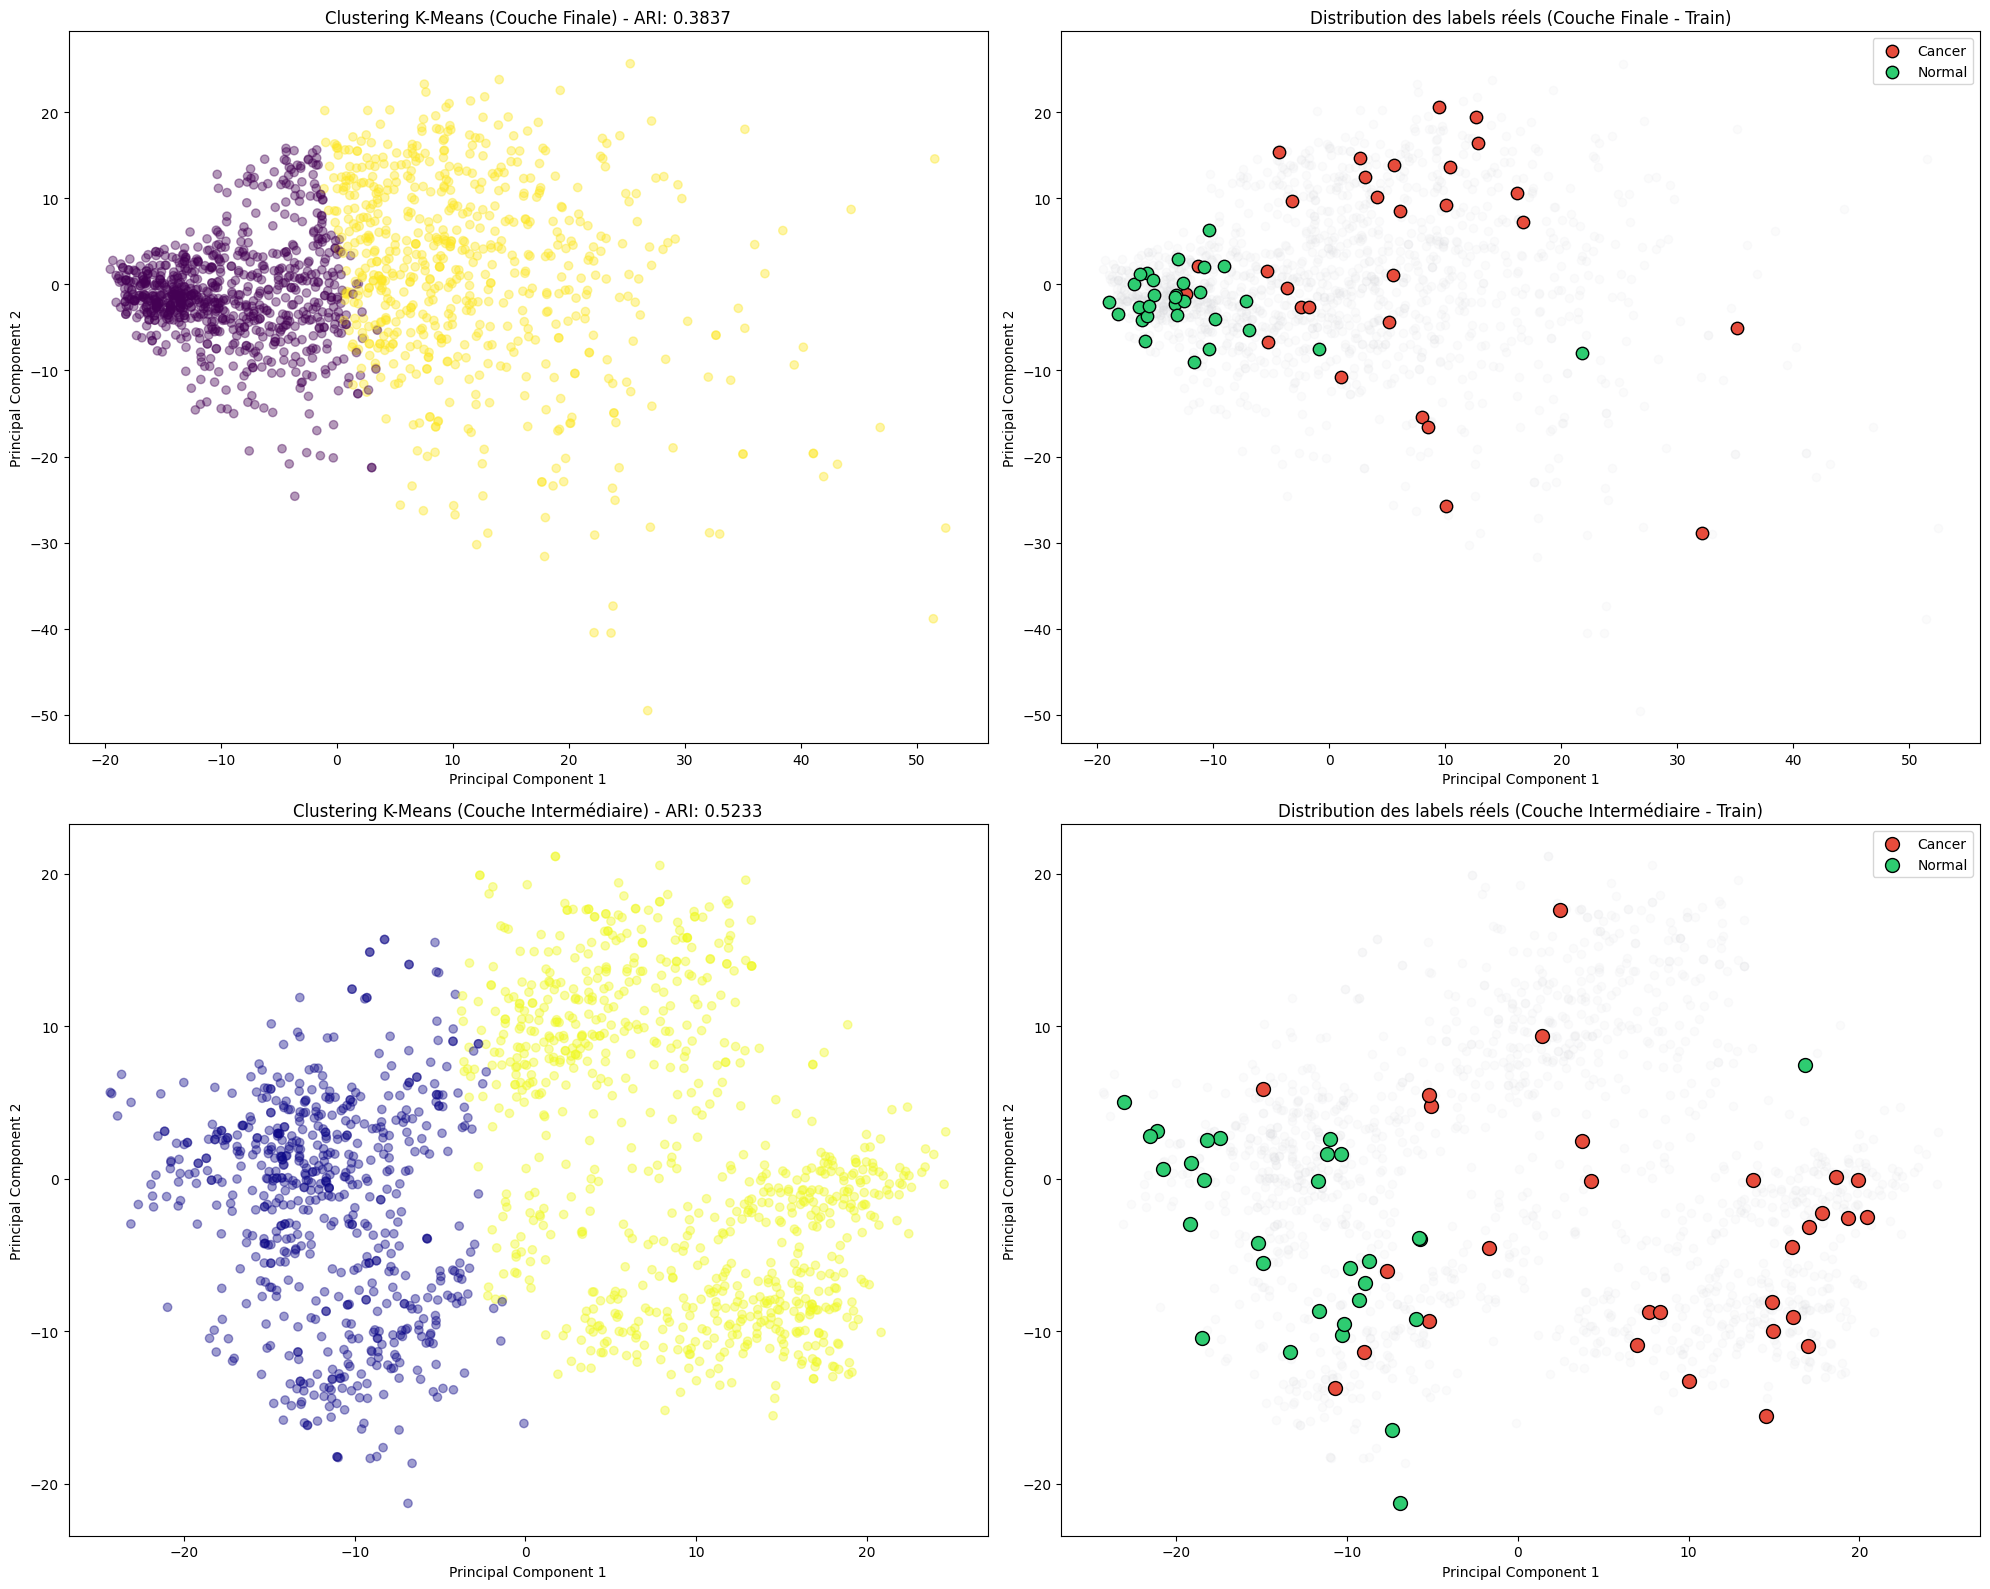

In [7]:
# Configuration des couleurs et styles
color_dict = {'cancer': '#e74c3c', 'normal': '#2ecc71', 'Unknown': '#dcdde1'}

# Création de la figure 2x2
fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# --- LIGNE 1 : COUCHE FINALE ---
axes[0, 0].scatter(X_pca_final[:, 0], X_pca_final[:, 1], c=clus_final, cmap='viridis', alpha=0.4)
axes[0, 0].set_title(f"Clustering K-Means (Couche Finale) - ARI: {ari_final:.4f}")

axes[0, 1].scatter(X_pca_final[~mask_labeled_train, 0], X_pca_final[~mask_labeled_train, 1], c='#dcdde1', alpha=0.1)
for lbl in ['cancer', 'normal']:
    m = df_train_clustering['label'] == lbl
    axes[0, 1].scatter(X_pca_final[m, 0], X_pca_final[m, 1], c=color_dict[lbl], s=80, edgecolors='black', label=lbl.capitalize())
axes[0, 1].set_title("Distribution des labels réels (Couche Finale - Train)")

# --- LIGNE 2 : COUCHE INTERMÉDIAIRE ---
axes[1, 0].scatter(X_pca_inter[:, 0], X_pca_inter[:, 1], c=clus_inter, cmap='plasma', alpha=0.4)
axes[1, 0].set_title(f"Clustering K-Means (Couche Intermédiaire) - ARI: {ari_inter:.4f}")

axes[1, 1].scatter(X_pca_inter[~mask_labeled_train, 0], X_pca_inter[~mask_labeled_train, 1], c='#dcdde1', alpha=0.1)
for lbl in ['cancer', 'normal']:
    m = df_train_clustering['label'] == lbl
    axes[1, 1].scatter(X_pca_inter[m, 0], X_pca_inter[m, 1], c=color_dict[lbl], s=100, edgecolors='black', label=lbl.capitalize())
axes[1, 1].set_title("Distribution des labels réels (Couche Intermédiaire - Train)")

# Mise en page
for ax in axes.flat:
    ax.set_xlabel("Principal Component 1")
    ax.set_ylabel("Principal Component 2")
axes[0, 1].legend()
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## CLAHE

Validation qualitative de l'amélioration de contraste (CLAHE)

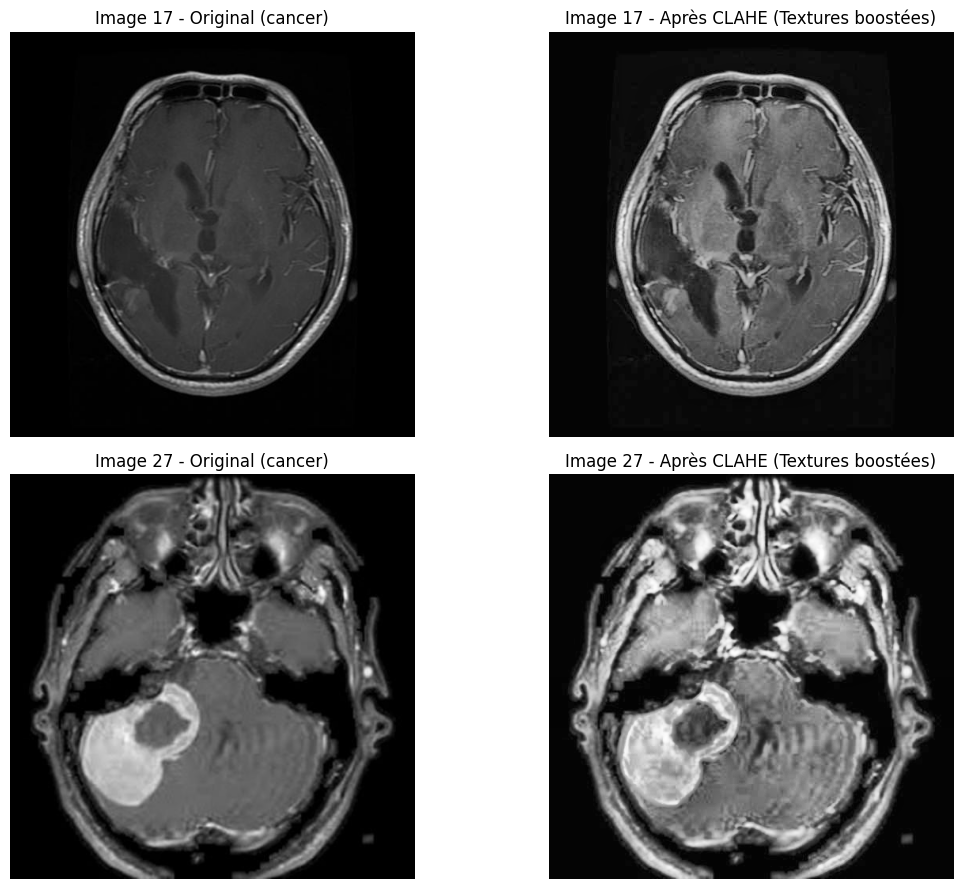

In [8]:
# --- CELLULE DE VALIDATION VISUELLE DU CLAHE ---

# 1. On définit les indices à tester (un cancer et un normal pour comparer)
indices_a_tester = [17, 27] 
clahe_transformer = ApplyCLAHE(clip_limit=3.0)

# 2. Création de la figure (2 lignes, 2 colonnes)
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for i, idx in enumerate(indices_a_tester):
    # Chargement
    path = df_features.iloc[idx]['path']
    label = df_features.iloc[idx]['label']
    img_orig = Image.open(path).convert('RGB')
    
    # Transformation
    img_boosted = clahe_transformer(img_orig)
    
    # Affichage Original
    axes[i, 0].imshow(img_orig)
    axes[i, 0].set_title(f"Image {idx} - Original ({label})")
    axes[i, 0].axis('off')
    
    # Affichage CLAHE
    axes[i, 1].imshow(img_boosted)
    axes[i, 1].set_title(f"Image {idx} - Après CLAHE (Textures boostées)")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

Chargement et audit de l'intégrité des descripteurs visuels

In [9]:
# 1. Chargement du DataFrame optimisé CLAHE
df_clahe = pd.read_pickle("../features/features_mri_clahe.pkl")

# 2. Vérification de l'intégrité
if 'resnet_inter_clahe' in df_clahe.columns:
    print(f"Colonnes CLAHE validées. Total images : {len(df_clahe)}")
else:
    print("Erreur : Colonne 'resnet_inter_clahe' manquante.")

# 3. Séparation stricte 60/10/30
df_labeled_clahe = df_clahe[df_clahe['label'] != 'Unknown'].copy()
df_unlabeled_clahe = df_clahe[df_clahe['label'] == 'Unknown'].copy()

train_val_labeled_clahe, test_df_clahe = train_test_split(
    df_labeled_clahe, test_size=0.30, stratify=df_labeled_clahe['label'], random_state=42
)
train_labeled_clahe, val_df_clahe = train_test_split(
    train_val_labeled_clahe, test_size=(0.10/0.70), stratify=train_val_labeled_clahe['label'], random_state=42
)

# 4. Préparation du jeu d'entraînement et des masques
train_clustering_clahe = pd.concat([df_unlabeled_clahe, train_labeled_clahe])

mask_clahe_train = train_clustering_clahe['label'] != 'Unknown'
true_labels_clahe_train = train_clustering_clahe[mask_clahe_train]['label'].map({'cancer': 1, 'normal': 0})

print(f"Données CLAHE prêtes et séparées. Entraînement: {len(train_clustering_clahe)} images.")

Colonnes CLAHE validées. Total images : 1506
Données CLAHE prêtes et séparées. Entraînement: 1465 images.


Évaluation du clustering sur descripteurs avec amélioration de contraste (CLAHE)

In [10]:
def run_clustering_clahe(column_name):
    X_train = np.stack(train_clustering_clahe[column_name].values)
    X_val = np.stack(val_df_clahe[column_name].values)
    X_test = np.stack(test_df_clahe[column_name].values)
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)
    
    pca = PCA(n_components=2)
    X_train_pca = pca.fit_transform(X_train_scaled)
    
    km = KMeans(n_clusters=2, n_init=10, random_state=42)
    train_clusters = km.fit_predict(X_train_scaled)
    
    val_clusters = km.predict(X_val_scaled)
    test_clusters = km.predict(X_test_scaled)
    
    train_clustering_clahe['weak_label'] = train_clusters
    val_df_clahe['weak_label'] = val_clusters
    test_df_clahe['weak_label'] = test_clusters
    
    score_ari = adjusted_rand_score(true_labels_clahe_train, train_clusters[mask_clahe_train])
    
    return X_train_pca, train_clusters, score_ari

# Lancement du clustering sur la colonne optimisée
X_pca_clahe, clus_clahe, ari_clahe = run_clustering_clahe('resnet_inter_clahe')

print(f"Score ARI avec CLAHE (Train) : {ari_clahe:.4f}")

Score ARI avec CLAHE (Train) : 0.2297


Lancement et comparaison

In [11]:
# Comparaison des performances
print("="*40)
print("BILAN DE PERFORMANCE")
print("="*40)
print(f"ARI Baseline (Intermédiaire) : {ari_inter:.4f}")
print(f"ARI Optimisé (CLAHE)       : {ari_clahe:.4f}")
print("-"*40)

# Calcul de l'évolution relative
gain_pourcentage = ((ari_clahe - ari_inter) / ari_inter) * 100
print(f"Évolution de la performance : {gain_pourcentage:+.2f}%")
print("="*40)

BILAN DE PERFORMANCE
ARI Baseline (Intermédiaire) : 0.5233
ARI Optimisé (CLAHE)       : 0.2297
----------------------------------------
Évolution de la performance : -56.11%


## CLAHE + CROP

Chargement et préparation des descripteurs issus du pipeline hybride

In [12]:
# 1. Chargement du DataFrame Hybride (Crop + CLAHE)
df_hybrid = pd.read_pickle("../features/features_mri_hybrid.pkl")

# 2. Séparation 60/10/30 pour isoler le test et la validation
df_labeled_hyb = df_hybrid[df_hybrid['label'] != 'Unknown'].copy()
df_unlabeled_hyb = df_hybrid[df_hybrid['label'] == 'Unknown'].copy()

train_val_labeled_hyb, test_df_hyb = train_test_split(
    df_labeled_hyb, test_size=0.30, stratify=df_labeled_hyb['label'], random_state=42
)
train_labeled_hyb, val_df_hyb = train_test_split(
    train_val_labeled_hyb, test_size=(0.10/0.70), stratify=train_val_labeled_hyb['label'], random_state=42
)

# Jeu d'entraînement complet pour le clustering
train_clustering_hyb = pd.concat([df_unlabeled_hyb, train_labeled_hyb])

# 3. On recalcule les labels de vérité terrain spécifiquement pour le TRAIN
mask_hybrid_train = train_clustering_hyb['label'] != 'Unknown'
true_labels_hybrid_train = train_clustering_hyb[mask_hybrid_train]['label'].map({'cancer': 1, 'normal': 0})

print(f"Données Hybrides chargées et séparées. Entraînement: {len(train_clustering_hyb)} images.")

Données Hybrides chargées et séparées. Entraînement: 1461 images.


Préparation et standardisation des données

In [13]:
def run_clustering_hybrid(column_name):
    # A. Extraction
    X_train = np.stack(train_clustering_hyb[column_name].values)
    X_val = np.stack(val_df_hyb[column_name].values)
    X_test = np.stack(test_df_hyb[column_name].values)
    
    # B. Standardisation (Fit sur le Train uniquement)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)
    
    # C. PCA & Clustering (Fit sur le Train uniquement)
    pca = PCA(n_components=2)
    X_train_pca = pca.fit_transform(X_train_scaled)
    
    km = KMeans(n_clusters=2, n_init=10, random_state=42)
    train_clusters = km.fit_predict(X_train_scaled)
    
    # D. Application sur Val et Test
    val_clusters = km.predict(X_val_scaled)
    test_clusters = km.predict(X_test_scaled)
    
    # E. Sauvegarde des labels dans les DataFrames
    train_clustering_hyb['weak_label'] = train_clusters
    val_df_hyb['weak_label'] = val_clusters
    test_df_hyb['weak_label'] = test_clusters
    
    # F. Calcul ARI sur les labels spécifiques au train
    score_ari = adjusted_rand_score(true_labels_hybrid_train, train_clusters[mask_hybrid_train])
    
    return X_train_pca, train_clusters, score_ari

# 1. On lance le calcul pour la version Hybride
X_pca_hyb, clus_hyb, ari_hybrid = run_clustering_hybrid('resnet_inter_hybrid')

Synthèse comparative et Benchmark des performances d'extraction

In [14]:

# 2. --- BILAN FINAL DE TOUTES LES STRATÉGIES ---
print("="*50)
print("COMPARAISON FINALE DES PERFORMANCES (ARI)")
print("="*50)
print(f"1. BASELINE (ResNet Inter)     : {ari_inter:.4f}")
print(f"2. CLAHE SEUL (Fond noir)      : {ari_clahe:.4f}")
print(f"3. HYBRIDE (Crop + CLAHE 2.0)  : {ari_hybrid:.4f}")
print("-"*50)

# 3. Calcul du gain final par rapport à la baseline
gain_final = ((ari_hybrid - ari_inter) / ari_inter) * 100
print(f"SCORE FINAL VS BASELINE : {gain_final:+.2f}%")
print("="*50)


COMPARAISON FINALE DES PERFORMANCES (ARI)
1. BASELINE (ResNet Inter)     : 0.5233
2. CLAHE SEUL (Fond noir)      : 0.2297
3. HYBRIDE (Crop + CLAHE 2.0)  : 0.4274
--------------------------------------------------
SCORE FINAL VS BASELINE : -18.33%


Cartographie de l'espace latent hybride et validation de la structure des clusters

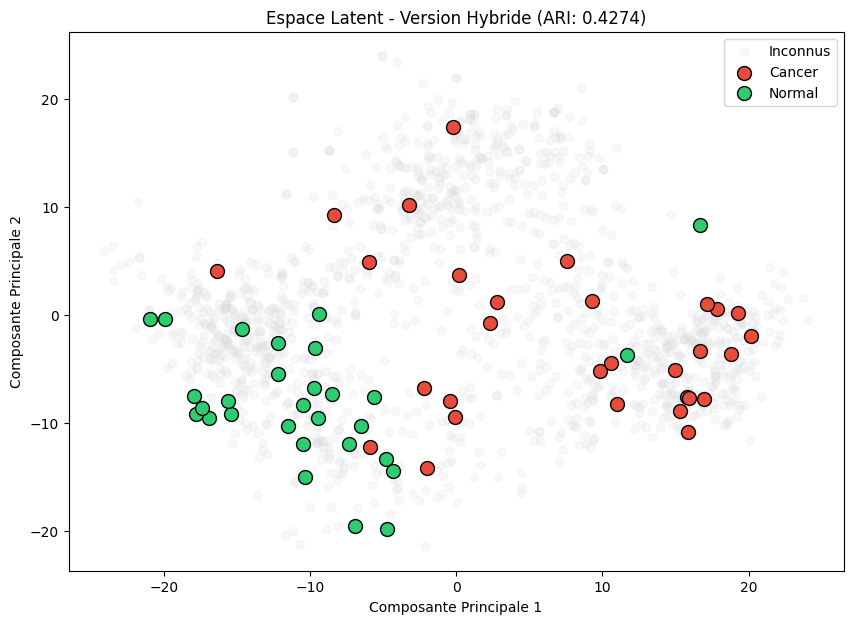

In [15]:
# 4. Visualisation de l'espace latent Hybride
plt.figure(figsize=(10, 7))
plt.scatter(X_pca_hyb[~mask_hybrid_train, 0], X_pca_hyb[~mask_hybrid_train, 1], c='#dcdde1', alpha=0.2, label='Inconnus')

for lbl, color in [('cancer', '#e74c3c'), ('normal', '#2ecc71')]:
    m = train_clustering_hyb['label'] == lbl
    plt.scatter(X_pca_hyb[m, 0], X_pca_hyb[m, 1], c=color, s=100, edgecolors='black', label=lbl.capitalize())

plt.title(f"Espace Latent - Version Hybride (ARI: {ari_hybrid:.4f})")
plt.xlabel("Composante Principale 1")
plt.ylabel("Composante Principale 2")
plt.legend()
plt.show()

In [16]:
# 1. Les labels (weak_label) ont déjà été insérés via la fonction run_clustering_hybrid

# 2. Sauvegarde des trois fichiers séparés pour le Notebook 4
train_clustering_hyb.to_pickle("../features/train_weak_labels.pkl")
val_df_hyb.to_pickle("../features/val_weak_labels.pkl")
test_df_hyb.to_pickle("../features/test_weak_labels.pkl")

print("Fichiers d'entraînement, validation et test sauvegardés AVEC la colonne weak_label !")

Fichiers d'entraînement, validation et test sauvegardés AVEC la colonne weak_label !
